In [1]:
## 2026.08.20 CODEX PDAC twin of CODEX_hcc/HCC_train_validate_cv_UNIlabel_single.ipynb
## Train + validate on **one** annotated core (s1167 ACQUISITION_ID).
## Cross-dataset notebook: PDAC_train_validate_cv_UNIlabel_all.ipynb
##
## CLI equivalent:
##   conda run --no-capture-output -n SeededNTM python -u \
##     code/CODEX_pdac/PDAC_train_validate_cv_UNIlabel.py --sample Charvill-94_c001_v001_r001_reg001
##
## Hierarchy (three-head):
##   L2  = final_CT          (fine / celltype_level2)
##   L12 = final_sublineage  (intermediate / celltype_level1)
##   L1  = final_lineage     (coarse / celltype_level0)
##
## Preprocess this core first:
##   conda run -n SeededNTM python code/CODEX_pdac/match_codex_cells_with_pixel.py \
##     --acq-id Charvill-94_c001_v001_r001_reg001
##   ACQ_ID=Charvill-94_c001_v001_r001_reg001 bash code/CODEX_pdac/demo_GT_feature_extraction_Single.sh gt
##   ACQ_ID=Charvill-94_c001_v001_r001_reg001 bash code/CODEX_pdac/demo_GT_feature_extraction_Single.sh stardist
## Env: conda activate SeededNTM  (or Hist2Pheno)


## Set env


In [2]:
import os
import warnings
warnings.filterwarnings("ignore")
os.environ.setdefault("NCRT_CUDA_DEVICE", "0")
import sys as _sys
_pkg_dir = "/home/lingyu/ssd2/Python/Hist2Pheno/code/Hist2Pheno_pkg"
if _pkg_dir not in _sys.path:
    _sys.path.insert(0, _pkg_dir)
from runtime_env import configure_notebook_runtime
_rt_env = configure_notebook_runtime()
NCRT_PHYSICAL_GPU = _rt_env["physical_gpu"]


CUDA_VISIBLE_DEVICES=0 (physical GPU 0)


## Load Hist2Pheno


In [3]:
import sys
import importlib
import pandas as pd
from pathlib import Path

path = "/home/lingyu/ssd2/Python/"
for _d in (
    f"{path}Hist2Pheno/code/Hist2Pheno_pkg",
    f"{path}Hist2Pheno/code/CODEX_pdac",
):
    if _d not in sys.path:
        sys.path.insert(0, _d)

import base
import plot
import model as model_pkg
importlib.reload(base)
importlib.reload(plot)
importlib.reload(model_pkg)

import uni_label_cv_helpers as uni_nb
importlib.reload(uni_nb)

import PDAC_train_validate_cv_UNIlabel as pdac_cli
importlib.reload(pdac_cli)

from base import first_pth_tensor

print("Imports OK")
print(f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES')} (physical GPU {NCRT_PHYSICAL_GPU})")


Loading dependencies...
Loading dependencies...
Imports OK
CUDA_VISIBLE_DEVICES=0 (physical GPU 0)


## Define dataset


In [4]:
## One annotated PDAC TMA core (change SAMPLE to switch)
from uni_label_cv_helpers import RESULT_FIG, make_result_fig

S1167_ROOT = Path(f"{path}Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167")
CASES_ROOT = S1167_ROOT
STARDIST_ROOT = Path(
    os.environ.get(
        "STARDIST_ROOT",
        f"{path}Hist2Pheno/data/CODEX/HCC/StarDist_Segment_pdac/pdac_result",
    )
)

SAMPLE = "Charvill-94_c001_v001_r001_reg001"
therapy_data = SAMPLE
therapy_model = pdac_cli.DEFAULT_THERAPY_MODEL
save_result = pdac_cli.DEFAULT_PER_SAMPLE_SAVE_RESULT
PAN_ORGAN = pdac_cli.PAN_ORGAN

use_spatial_context = True
spatial_k = 8
spatial_mode = "mean"

acq_map = pdac_cli.load_he_acq_map(CASES_ROOT)
if SAMPLE not in acq_map:
    raise KeyError(f"Unknown PDAC ACQUISITION_ID={SAMPLE!r}")
acq_id = acq_map[SAMPLE]

SAMPLE_DIR = CASES_ROOT / SAMPLE
MODEL_DIR = SAMPLE_DIR / therapy_model
cell_coords_path = SAMPLE_DIR / f"{SAMPLE}_cells_with_pixel.csv"
celltype_pixel_stardist_path = SAMPLE_DIR / f"{SAMPLE}_cells_matched_by_stardist.csv"
stardist_raw_path = STARDIST_ROOT / SAMPLE / f"{SAMPLE}_Float_prob0.01_nms_0.3.csv"

print(f"therapy_data (ACQUISITION_ID) = {therapy_data}")
print(f"acq_id (CODEX)                = {acq_id}")
print(f"MODEL_DIR                     = {MODEL_DIR}")
print(f"STARDIST_ROOT                 = {STARDIST_ROOT}")
print(f"pan_organ                     = {PAN_ORGAN}")
print(f"spatial_context               = {use_spatial_context} (k={spatial_k}, mode={spatial_mode!r})")
print(f"GT cells CSV exists           = {cell_coords_path.is_file()}  → {cell_coords_path}")
print(f"StarDist-matched CSV          = {celltype_pixel_stardist_path.is_file()}  → {celltype_pixel_stardist_path}")
print(f"StarDist CSV                  = {stardist_raw_path.is_file()}  → {stardist_raw_path}")
print()
print("Feature extraction (from repo root):")
print(f"  ACQ_ID={SAMPLE} bash code/CODEX_pdac/demo_GT_feature_extraction_Single.sh gt")
print(f"  ACQ_ID={SAMPLE} bash code/CODEX_pdac/demo_GT_feature_extraction_Single.sh stardist")
print("Preprocess cell tables:")
print(f"  python code/CODEX_pdac/match_codex_cells_with_pixel.py --acq-id {SAMPLE}")


therapy_data (ACQUISITION_ID) = Charvill-94_c001_v001_r001_reg001
acq_id (CODEX)                = Charvill-94_c001_v001_r001_reg001
MODEL_DIR                     = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI
STARDIST_ROOT                 = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/StarDist_Segment_pdac/pdac_result
pan_organ                     = codex_pdac
spatial_context               = True (k=8, mode='mean')
GT cells CSV exists           = True  → /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/Charvill-94_c001_v001_r001_reg001_cells_with_pixel.csv
StarDist-matched CSV          = True  → /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/Charvill-94_c001_v001_r001_reg001_cells_matched_by_stardist.csv
StarDist CSV                  = True  → /home/lingyu/ssd2/Python/H

In [5]:
## Result figures under s1167/{SAMPLE}/{therapy_model}/result/
result_fig, _result_dir_path = make_result_fig(
    CASES_ROOT, therapy_data, therapy_model, save_result
)
FIG = RESULT_FIG
BEST_MLP_PATH = MODEL_DIR / "best_mlp_gpu.pt"
print("result_dir =", _result_dir_path)
print("best_mlp  =", BEST_MLP_PATH)


result_dir = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result
best_mlp  = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/best_mlp_gpu.pt


In [6]:
## CUDA/CPU sanity check + reproducibility
import torch
import random
import numpy as np

print(sys.executable)
print(
    f"torch {torch.__version__} | built with CUDA: {torch.version.cuda} | "
    f"cuda.is_available: {torch.cuda.is_available()}"
)
pdac_cli.setup_cuda(os.environ.get("NCRT_CUDA_DEVICE", "0"))
device = pdac_cli.setup_device(allow_cpu=False)
SEED = 42
pdac_cli.setup_seed(SEED)
print(f"device: {device}")


/nobackup2/users/lingyu/conda_envs/SeededNTM/bin/python
torch 2.9.1+cu130 | built with CUDA: 13.0 | cuda.is_available: True
device: cuda:0


### Load image feature


In [7]:
hist_embedding_dir = MODEL_DIR / "ImgEmbeddings_all" / "sc_pth_16_16"
print(hist_embedding_dir)
if hist_embedding_dir.is_dir():
    tensor = first_pth_tensor(hist_embedding_dir)
else:
    print("UNI embedding dir missing — run demo_GT_feature_extraction_Single.sh gt first.")


/home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/ImgEmbeddings_all/sc_pth_16_16
Found file: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/ImgEmbeddings_all/sc_pth_16_16/sc_Charvill-94_c001_v001_r001_reg001_1219_2007.pth
Loaded type: <class 'tuple'>
tensor.shape of the first .pth file: torch.Size([1, 1, 1024])


Example UNI embedding dir for this PDAC core:

`s1167/{ACQUISITION_ID}/project_all_UNI/ImgEmbeddings_all/sc_pth_16_16`

Each `.pth` is typically `torch.Size([1, 1, 1024])`.


## Cell Type Classification Model

Per-sample stratified K-fold on **one** annotated PDAC core (not the 278-core pooled notebook).
CLI twin: `PDAC_train_validate_cv_UNIlabel.py --sample Charvill-94_c001_v001_r001_reg001`.


In [8]:
## Build per-sample RunContext (mirrors CLI --mode per-sample)

ctx = pdac_cli.RunContext(
    sample=SAMPLE,
    cases_root=CASES_ROOT,
    python_root=Path(path),
    therapy_data=therapy_data,
    therapy_model=therapy_model,
    save_result=save_result,
    device=device,
    seed=SEED,
    match_tolerance=1.0,
    column_rename=dict(pdac_cli.HCC_COLUMN_RENAME),
    force_rebuild_h5ad=False,
    input_dim=None,
    hidden_dims=(1024, 512, 256),
    cv_k=5,
    stratify_target="joint",
    patience=10,
    max_epochs=50,
    train_batch_size=pdac_cli.DEFAULT_TRAIN_BATCH_SIZE,
    resume_from_checkpoints=True,
    ablation_tag=pdac_cli.DEFAULT_ABLATION_TAG,
    hce_w1=1.0, hce_w2=2.0, hce_w12=1.0, hce_w_l12head=1.0, hce_w_l3=1.0, hce_w_l4=1.0,
    build_stardist_h5ad=True,
    acq_id=acq_id,
    stardist_root=STARDIST_ROOT,
    val_selection_metric=pdac_cli.DEFAULT_VAL_SELECTION_METRIC,
    cv_selection_metric=pdac_cli.DEFAULT_CV_SELECTION_METRIC,
    auto_cv_k=True,
    use_spatial_context=use_spatial_context,
    spatial_k=spatial_k,
    spatial_mode=spatial_mode,
)
print(f"ctx.sample_dir = {ctx.sample_dir}")
print(f"matched HE h5ad = {ctx.matched_he_h5ad}")
print(f"matched StarDist h5ad = {ctx.matched_stardist_h5ad}")


ctx.sample_dir = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001
matched HE h5ad = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/Charvill-94_c001_v001_r001_reg001_matched_features.h5ad
matched StarDist h5ad = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/Charvill-94_c001_v001_r001_reg001_matched_features_stardist.h5ad


## §1 Match UNI embeddings → HE h5ad and prepare CV


In [9]:
pdac_cli.step_he_h5ad(ctx)
pdac_cli.step_prepare_cv(ctx)
adata = ctx.g["adata"]
print(adata)
print("obs columns:", list(adata.obs.columns))
print("obsm keys:", list(adata.obsm.keys()))



[HE h5ad] Charvill-94_c001_v001_r001_reg001_matched_features.h5ad
  ✓ matched h5ad cache found; loading /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/Charvill-94_c001_v001_r001_reg001_matched_features.h5ad
  ✓ Loaded h5ad: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/Charvill-94_c001_v001_r001_reg001_matched_features.h5ad (5,981 cells × 1024 features)
  → 5,981 cells × 1024 features

Leave-one-group-out prep (filtered data):
  Samples: 5981, features: 1024
  Level2 classes: 11
  Level1 classes: 4
  Level12 classes: 6
  Coordinates: (5981, 2)
  Groups (for LOGO): 5981 unique
  Three-head training (HCC): L2=final_CT, L12=final_sublineage, L1=final_lineage
  input_dim=1024
  spatial: k=8, mode='mean', kNN index (5981, 8)
AnnData object with n_obs × n_vars = 5981 × 1024
    obs: 'final_CT', 'final_lineage', 'final_sublineage', 'tma'
    uns: 'cell_coords_p

## §2 MLP classifier (stratified K-fold)


In [10]:
pdac_cli.step_train(ctx)
LP = ctx.g["LP"]
print("BEST_MLP_CHECKPOINT =", ctx.g.get("BEST_MLP_CHECKPOINT"))
print("best_epoch =", LP.get("best_epoch"))
print("val_acc (L2) =", LP.get("val_acc"))
print("val_macro_f1 (L2) =", LP.get("val_macro_f1"))



[Train] stratified_kfold tag=D_emph_L2 k=5 stratify='joint'
  val_sel=three_tier_auc_sum cv_sel=three_tier_auc_sum spatial_k=8 mode='mean'
Spatial context: k=8, mode='mean', per-sample kNN, neighbor_index shape=(5981, 8)
Train dataset size: 4784
Val dataset size: 1197
Batch size: 4096
Feature dimension: 1024

KFold fold 0: stratify='joint'
  Resume: checkpoint exists, skip training -> /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/ablation_kfold_ckpts/D_emph_L2/hce_kfold_fold_0.pt
checkpoint_exists=True: loading checkpoint (no training): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/ablation_kfold_ckpts/D_emph_L2/hce_kfold_fold_0.pt
Loaded existing checkpoint metrics: accuracy=0.4770, weighted_f1=0.5148, macro_f1=0.2238
Train dataset size: 4785
Val dataset size: 1196
Batch size: 4096
Feature dimension: 1024

KF

## §3 Internal validation — L2 / L12 / L1



[HE validate] confusion matrices

L2 celltype
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/conf_matrix_level2.pdf


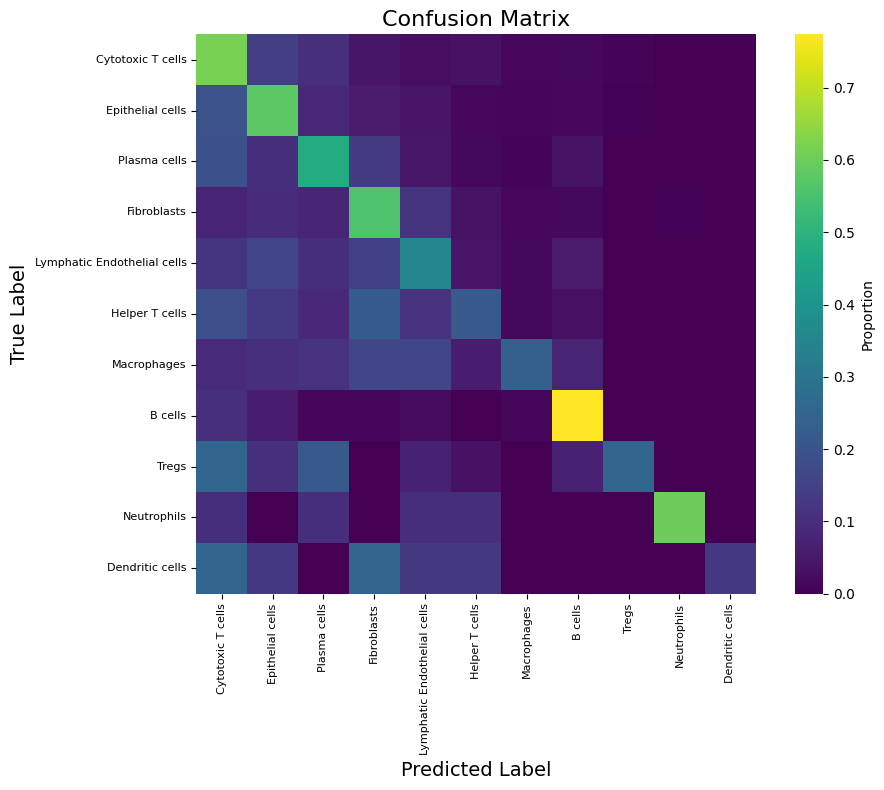


L1 lineage (L2→L1 agg)
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/conf_matrix_level1.pdf


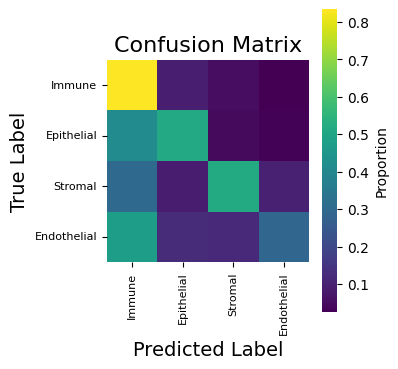


L1 lineage (L1 head)
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/conf_matrix_level1_L1head.pdf


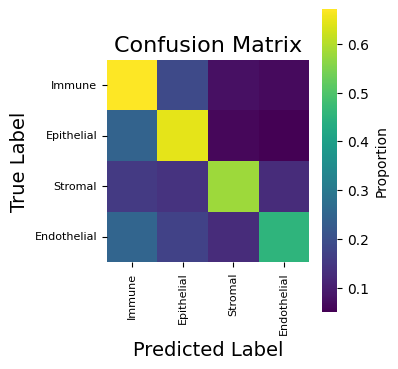


L12 sublineage
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/conf_matrix_level12.pdf


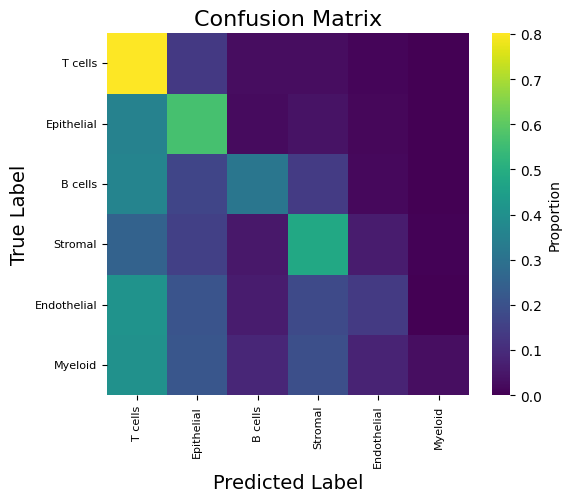

Skip L3 CNiche: no val_preds_level3 (re-run ablation cell after reload model/base)
Skip L4 TNiche: no val_preds_level4 (re-run ablation cell after reload model/base)
L1 agg vs L1 head agreement: 0.780638689182411
Current run metrics:
             timestamp                                therapy_data  \
0  2026-08-21 01:04:04  Charvill-94_c001_v001_r001_reg001_kfold_CV   

   best_epoch hce_lambda  hce_w1  hce_w2  hce_w12  hce_w_l12head  hce_w_l3  \
0           0       None     1.0     2.0      1.0            1.0       1.0   

   hce_w_l4  ...  insample_l1_macro_f1  insample_l1_weighted_f1  \
0       1.0  ...              0.543729                 0.704143   

   insample_l1_head_accuracy  insample_l1_head_macro_f1  \
0                   0.644207                     0.5341   

   insample_l1_head_weighted_f1  insample_l12_accuracy  insample_l12_macro_f1  \
0                      0.662046               0.616118               0.396549   

   insample_l12_weighted_f1  num_l1_head_classes  n

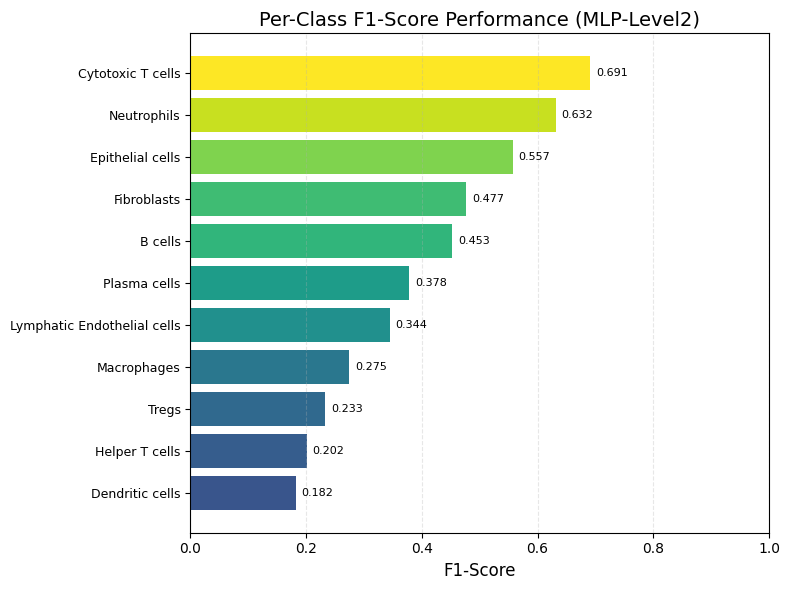


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 11
  Actual classes in test set: 11
  Feature dimension: 1024
  Model parameters: 2,764,309
  Best epoch: 0
  Test Accuracy: 0.5526
  Test Macro F1: 0.4021
  Test Weighted F1: 0.5657
Visualizing per-class performance...
  ✓ Computed metrics for 4 classes
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/f1_perclass_level1.pdf


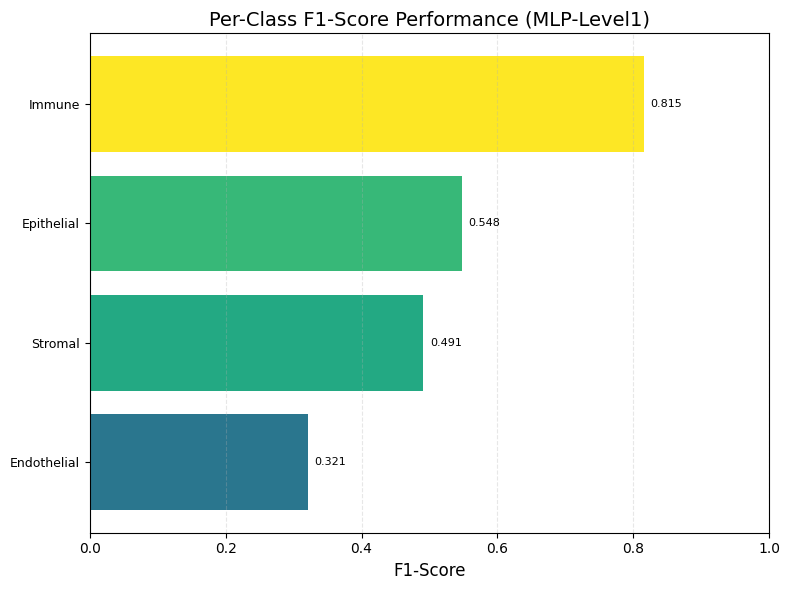


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 4
  Actual classes in test set: 4
  Feature dimension: 1024
  Model parameters: 2,764,309
  Best epoch: 0
  Test Accuracy: 0.7091
  Test Macro F1: 0.5437
  Test Weighted F1: 0.7041
Visualizing per-class performance...
  ✓ Computed metrics for 4 classes
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/f1_perclass_level1_L1head.pdf


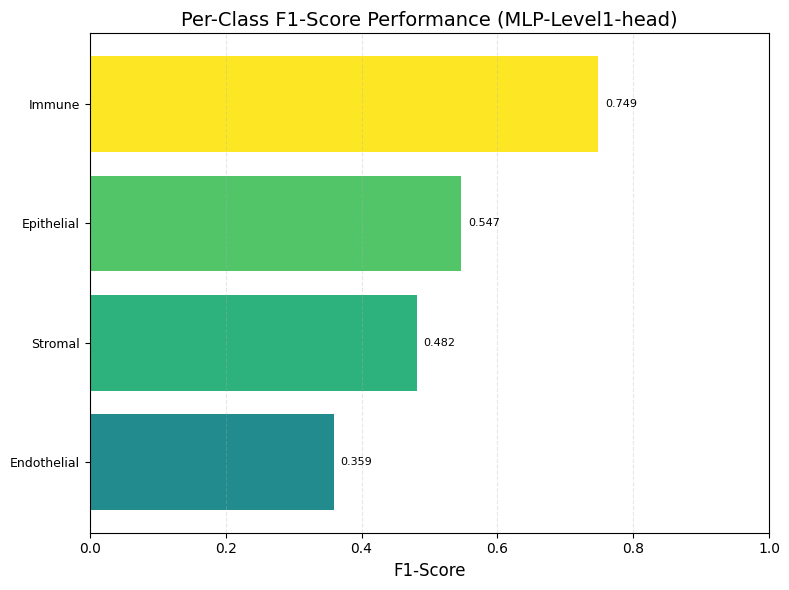


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 4
  Actual classes in test set: 4
  Feature dimension: 1024
  Model parameters: 2,764,309
  Best epoch: 0
  Test Accuracy: 0.7091
  Test Macro F1: 0.5437
  Test Weighted F1: 0.7041

L12 sublineage
Visualizing per-class performance...
  ✓ Computed metrics for 6 classes
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/f1_perclass_level12.pdf


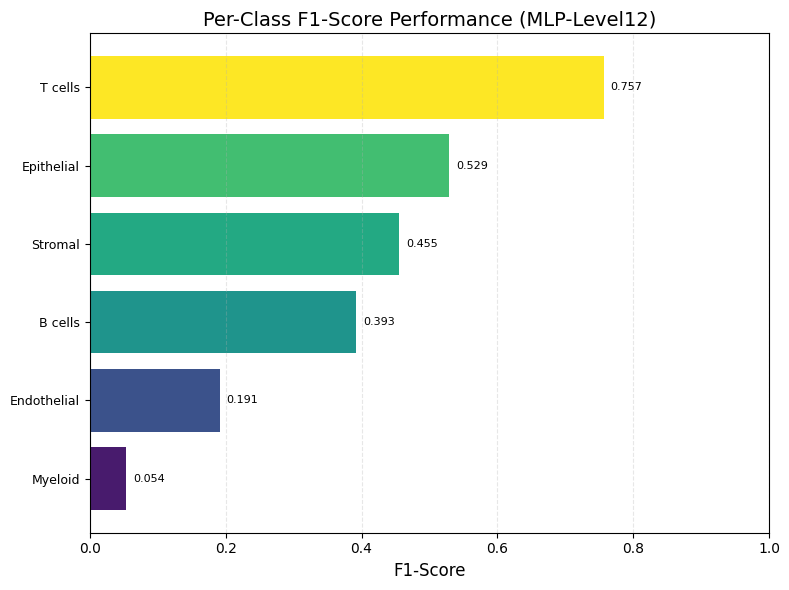


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 6
  Actual classes in test set: 6
  Feature dimension: 1024
  Model parameters: 2,764,309
  Best epoch: 0
  Test Accuracy: 0.6161
  Test Macro F1: 0.3965
  Test Weighted F1: 0.5949
Skip L3 CNiche per-class F1: no val_preds_level3
Skip L4 TNiche per-class F1: no val_preds_level4
[HE validate] spatial plots
  Using provided X and y...
  ✓ Using provided y strings as original labels for spatial TRUE plot.
  X_all_scaled shape: (5981, 1024)
  y_all_encoded shape: (5981,)
  ✓ Final y_all_encoded dtype: int64
X_all_scaled:  (5981, 1024)
y_all_encoded:  (5981,)
  Total samples: 5981
  DataLoader batch_size: 1024, num_workers: 4

Final Performance on All Data:
  Accuracy: 0.5250
  Macro F1-score: 0.4195
  Weighted F1-score: 0.5447
all_preds:  (5981,)
unique_labels:  (11,)

Detailed Classification Report:
  Number of classes: 11
                             precision    recall  f1-score   support

                    B cells  

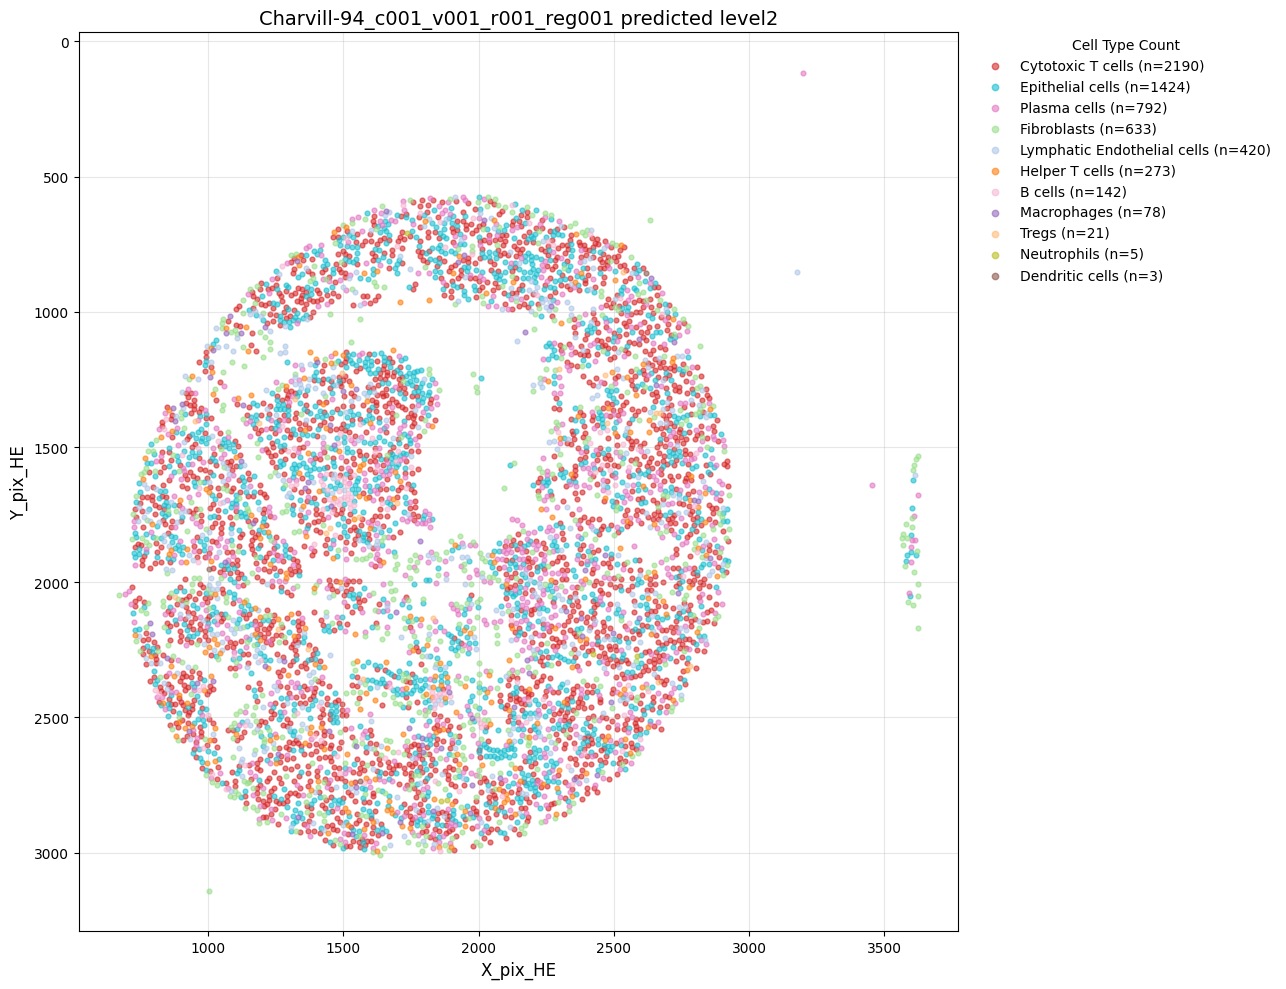


Plotting spatial distribution of TRUE level2 cell types...
Number of valid data points: 5981
Number of cell types: 11


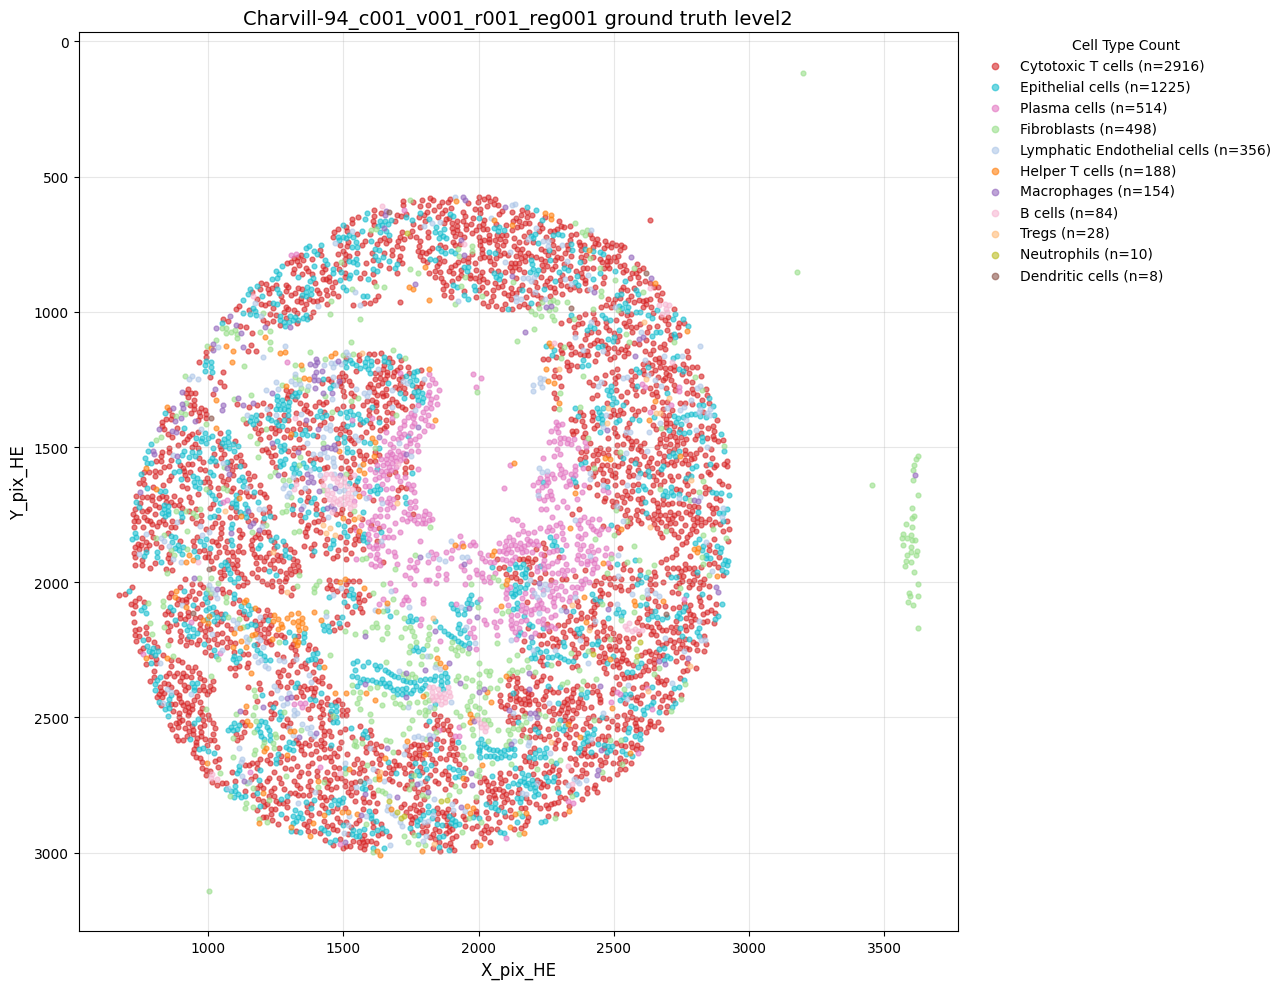

Number of valid data points: 5981
Number of cell types: 4


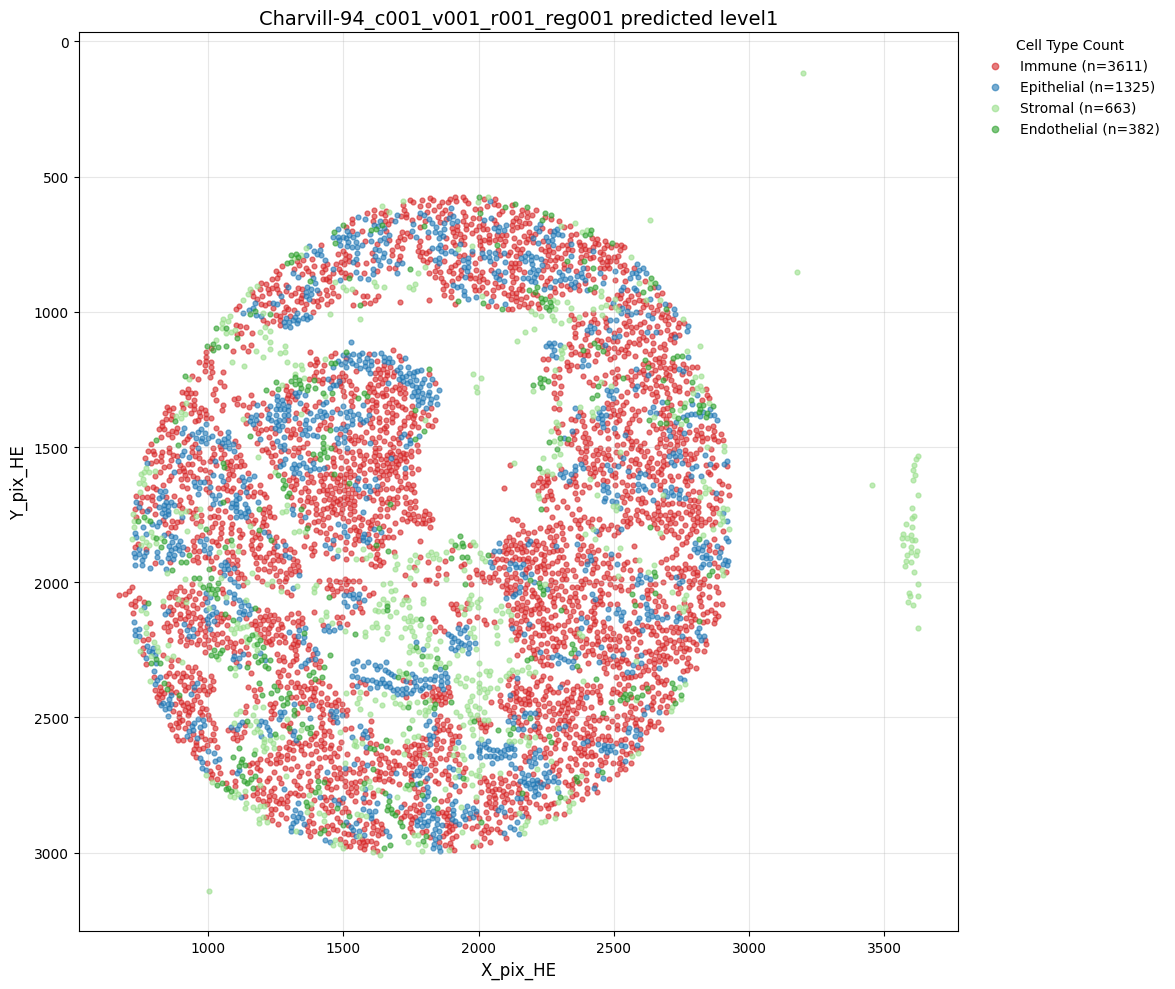

  Saved level1 predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/celltype_valid_level1.jpg
Number of valid data points: 5981
Number of cell types: 4


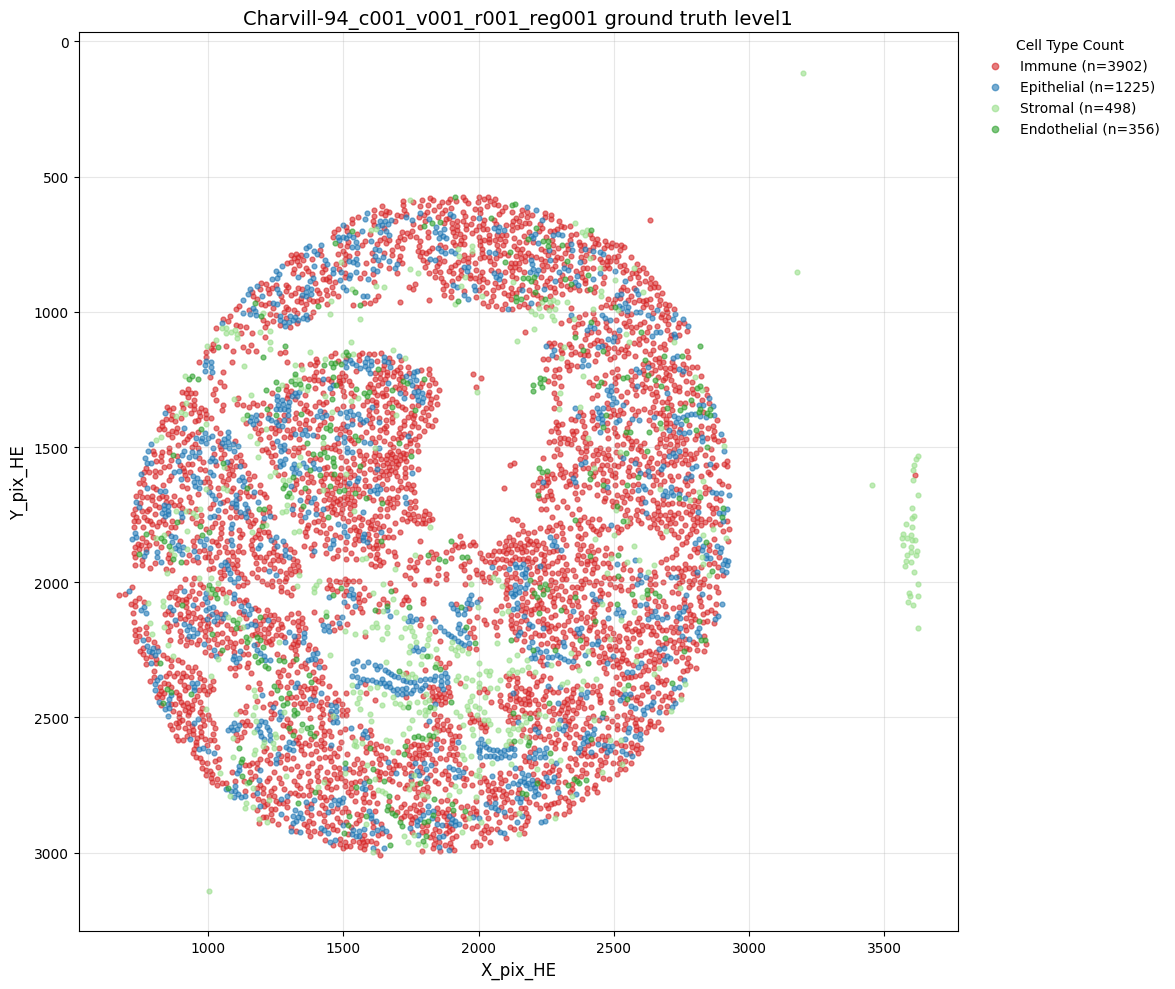

  Saved level1 true spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/celltype_true_level1.jpg

L12 sublineage
Number of valid data points: 5981
Number of cell types: 6


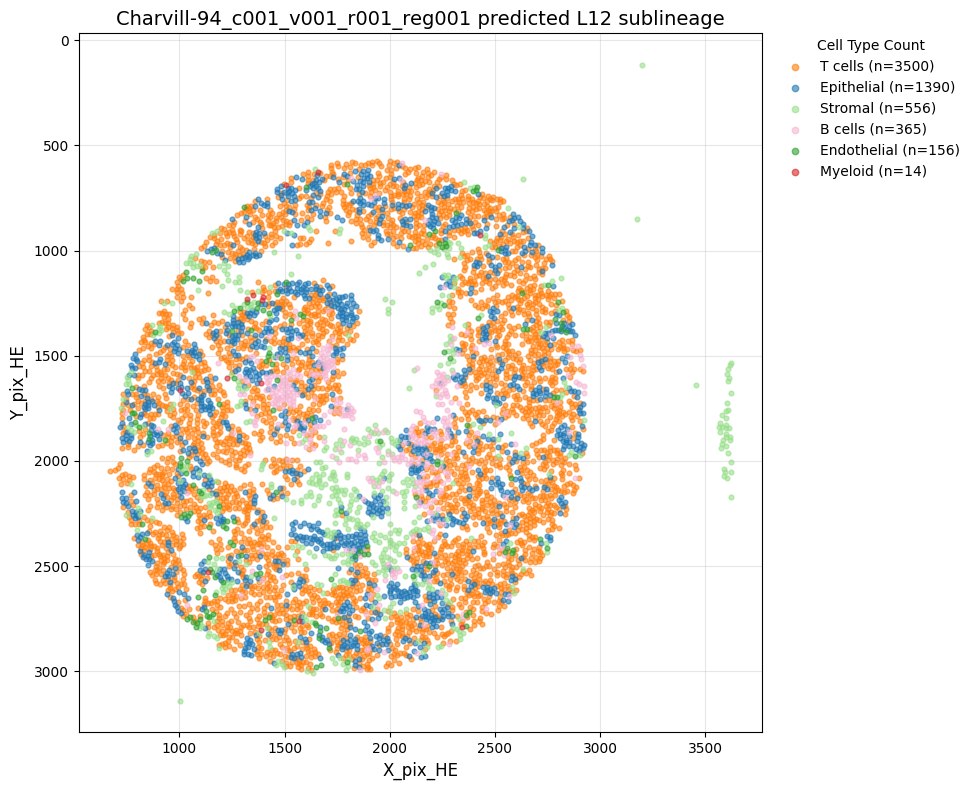

  Saved predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/celltype_valid_level12.jpg
Number of valid data points: 5981
Number of cell types: 6


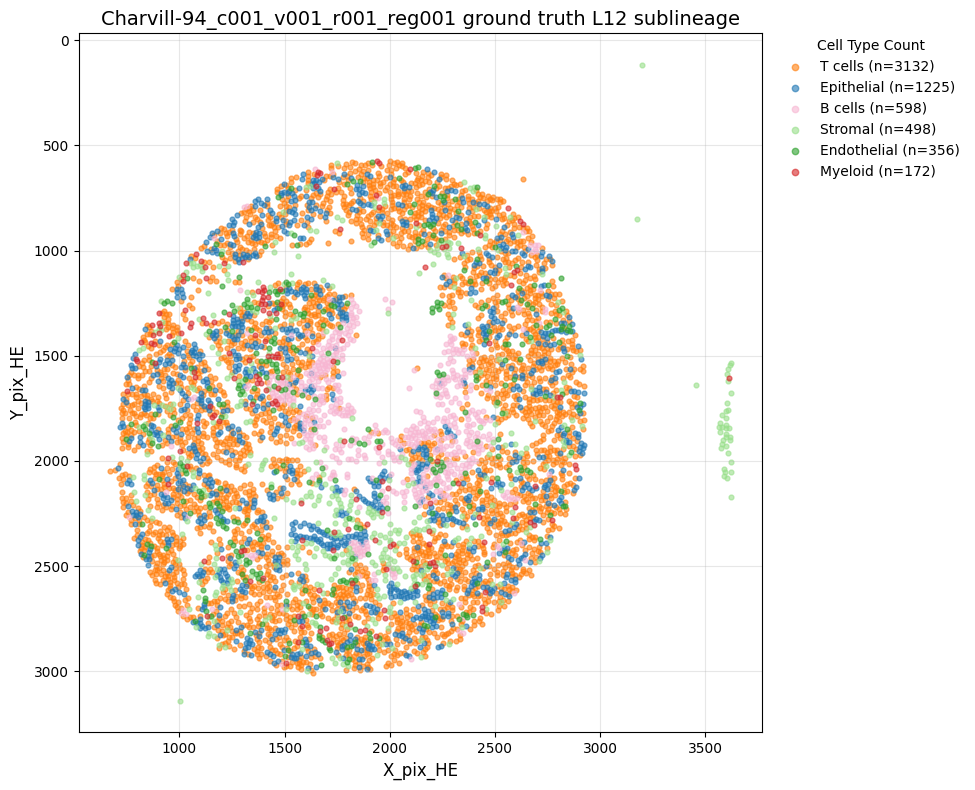

  Saved ground-truth spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/celltype_true_level12.jpg
Skip L3 CNiche spatial: no val_preds_level3
Skip L4 TNiche spatial: no val_preds_level4
Internal metrics CSV: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/validation_internal_metrics.csv


In [11]:
## Confusion matrices, per-class F1, spatial pred vs GT (writes under result/)
pdac_cli.step_he_validate(ctx)
print("Internal metrics CSV:", ctx.result_fig("validation_internal_metrics"))


## Predict StarDist


  StarDist h5ad exists: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/Charvill-94_c001_v001_r001_reg001_matched_features_stardist.h5ad

[StarDist] load model from /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/best_mlp_gpu.pt
Loading best model for StarDist prediction...
  Checkpoint file: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/best_mlp_gpu.pt
  Inferred hidden_dims from checkpoint: [1024, 512, 256]
✓ StarDist model loaded
  Loading data from matched_features_path...
  ✓ Loaded X from /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/Charvill-94_c001_v001_r001_reg001_matched_features_stardist.h5ad: (5981, 1024)
  ✓ Loaded y from /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HC

Predicting: 100%|██████████| 6/6 [00:00<00:00, 16.25it/s]



Prediction completed:
  Total predictions: 5981
  Predicted classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  ✓ Using original labels for visualization: 5981 labels
  ✓ Computed metrics in prediction_only mode from aligned true labels: acc=0.4872, macro_f1=0.2324, weighted_f1=0.5019

Preparing spatial distribution plot...
  Matching predictions with coordinates...
  ✓ Loaded coordinates from /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/Charvill-94_c001_v001_r001_reg001_matched_features_stardist.h5ad: (5981, 2)
  Coordinates shape: (5981, 2)
  Predictions shape: (5981,)
  ✓ Created prediction DataFrame with 5981 cells

Plotting spatial distribution of PREDICTED level2 cell types...
Number of valid data points: 5981
Number of cell types: 11


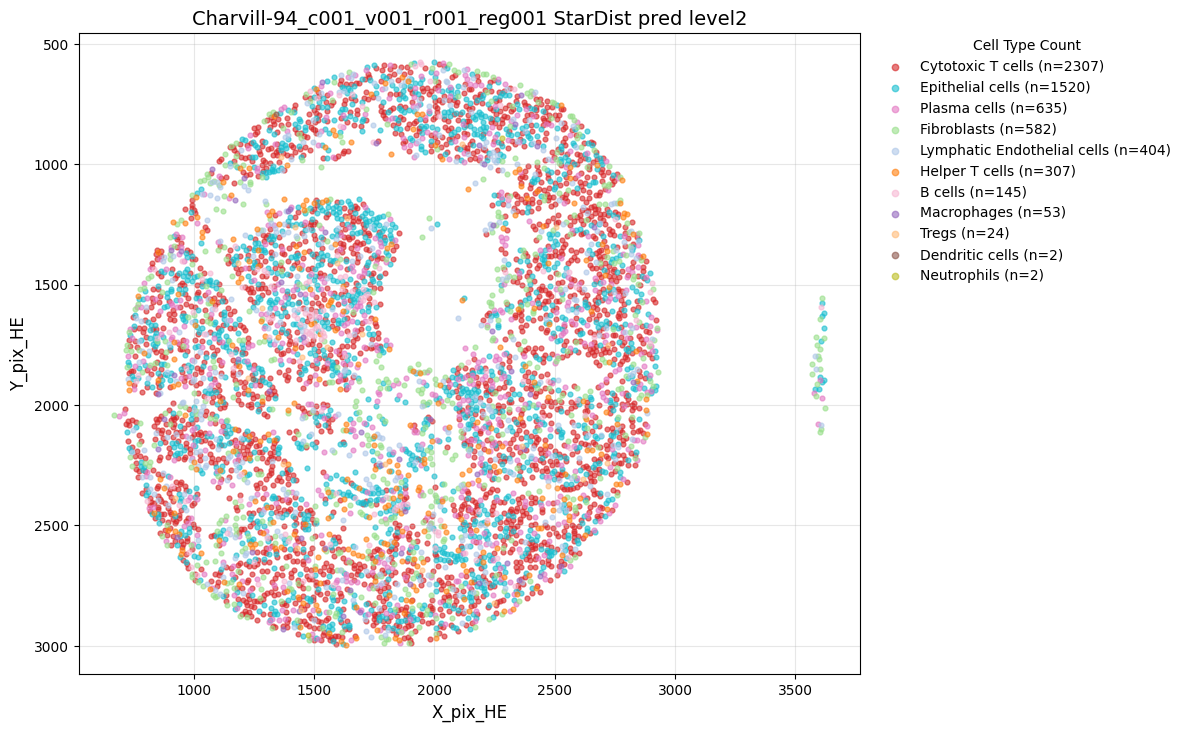


Plotting spatial distribution of TRUE level2 cell types...
Number of valid data points: 5981
Number of cell types: 11


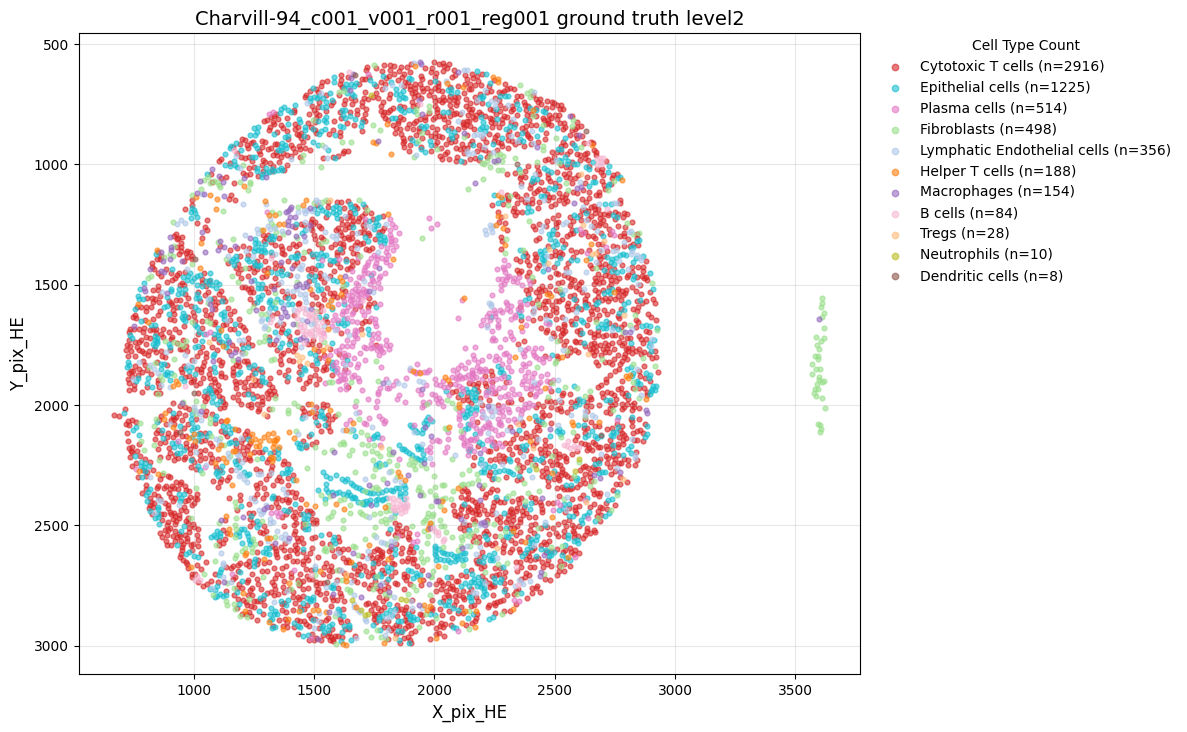

Number of valid data points: 5981
Number of cell types: 4


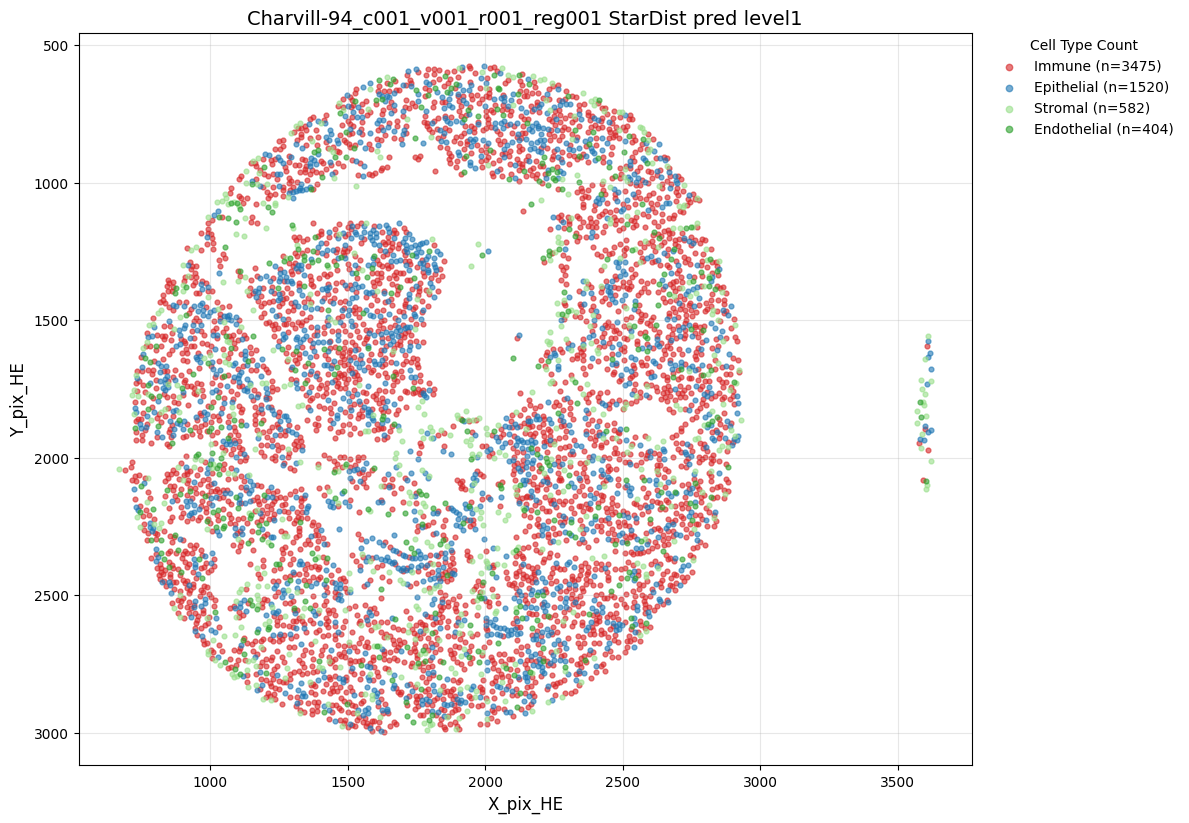

  Saved level1 predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/celltype_pred_stardist_level1.jpg
Number of valid data points: 5981
Number of cell types: 4


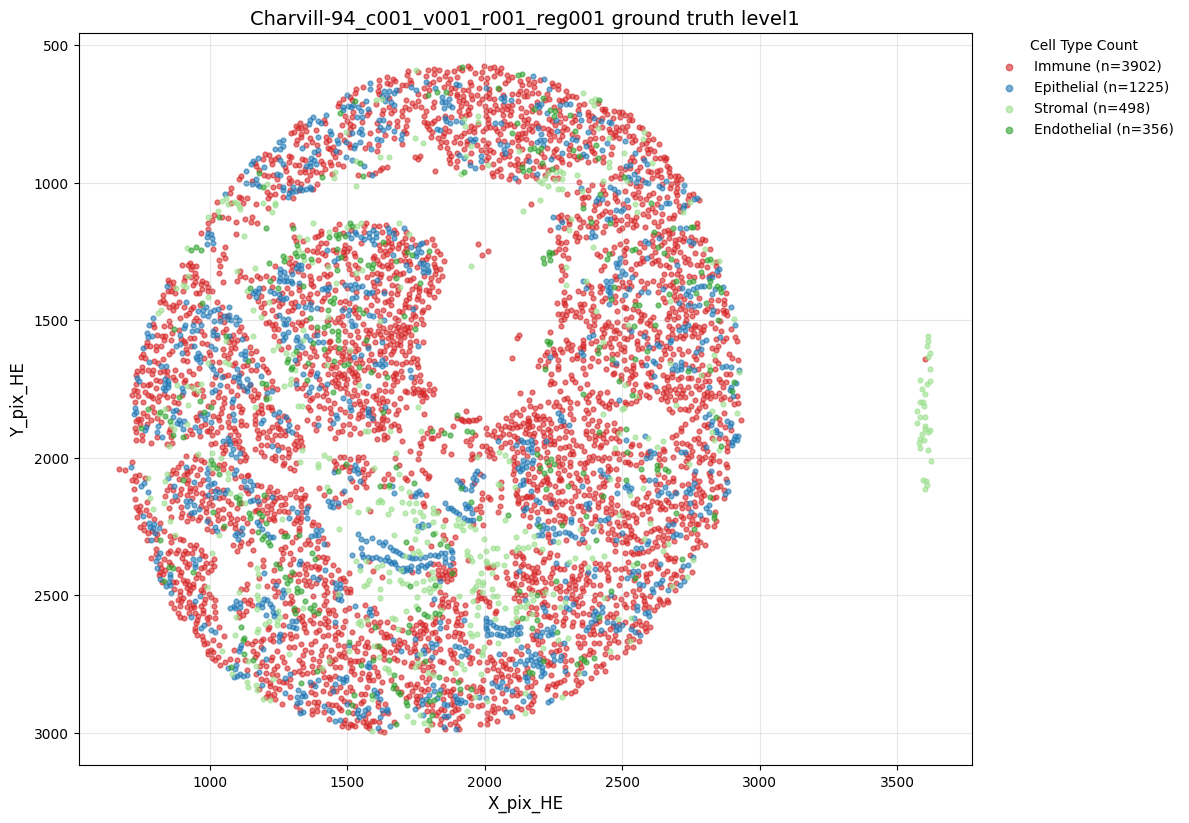


L12 sublineage (StarDist)
Number of valid data points: 5981
Number of cell types: 6


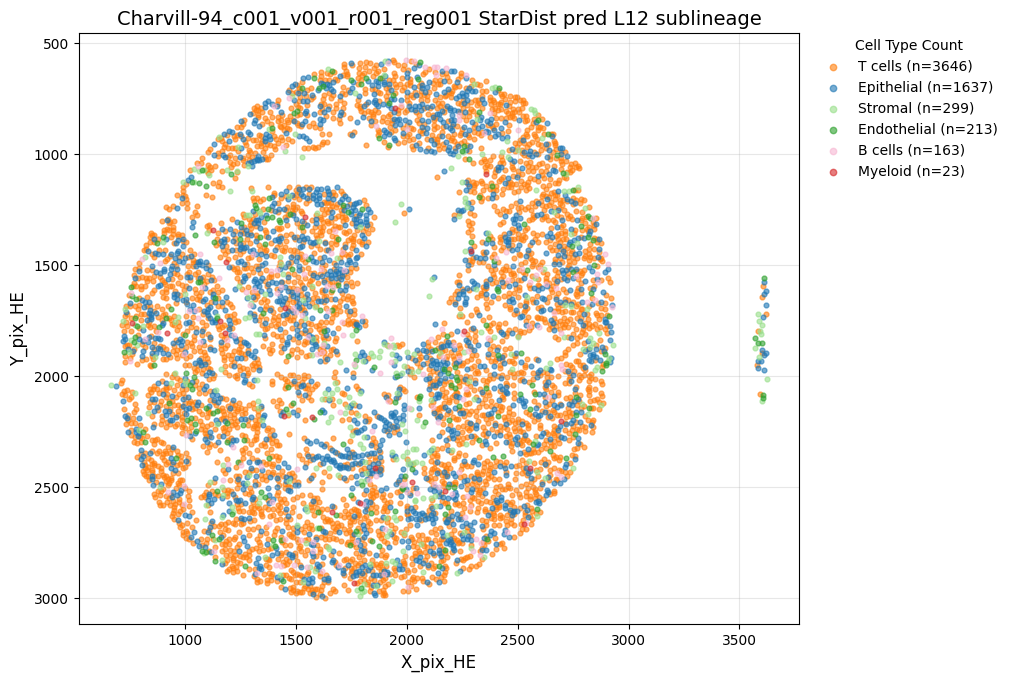

  Saved predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/celltype_pred_stardist_level12.jpg
Number of valid data points: 5981
Number of cell types: 6


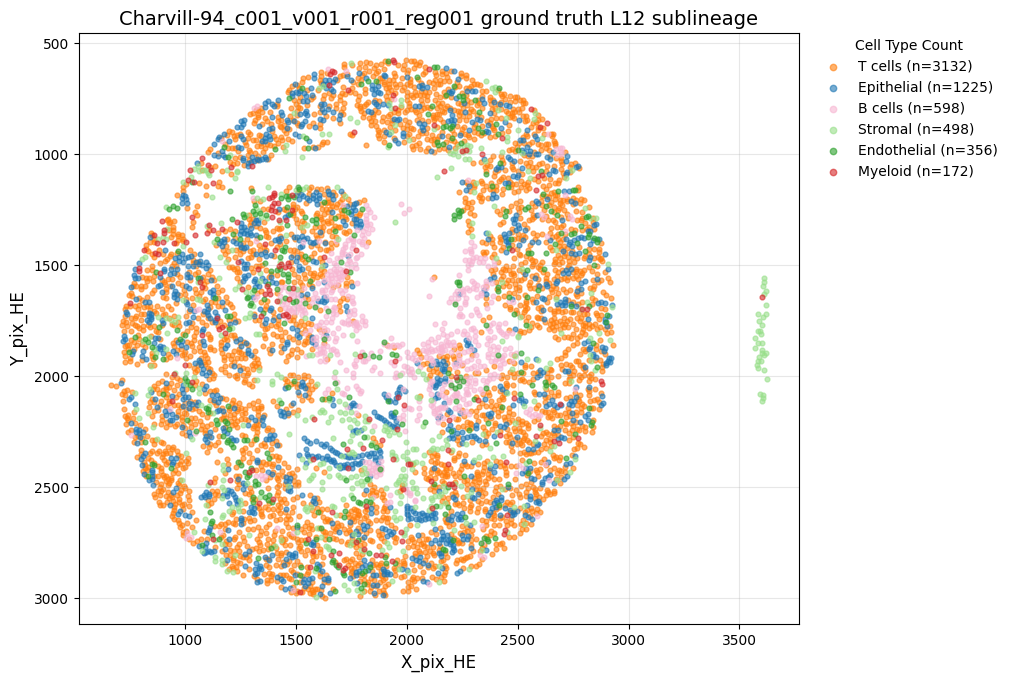

  Saved ground-truth spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/celltype_true_stardist_level12.jpg
Saved: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/celltype_pred_stardist_level12.jpg
Skip L3 CNiche: missing preds_l3
Skip L4 TNiche: missing preds_l4
[StarDist] ROC curves
  ROC colors: codex_pdac_fine (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/roc_stardist_level2.pdf


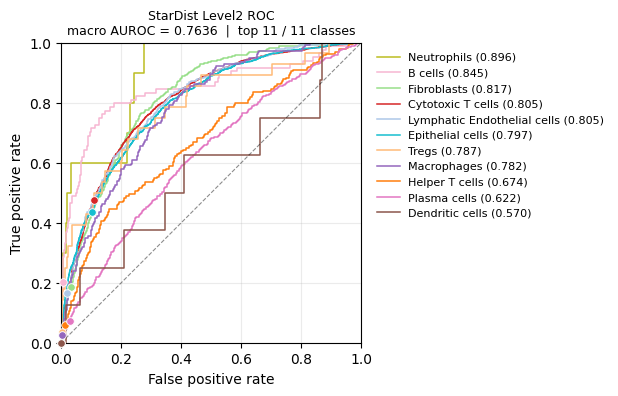

  ROC colors: codex_pdac_coarse (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/roc_stardist_level1.pdf


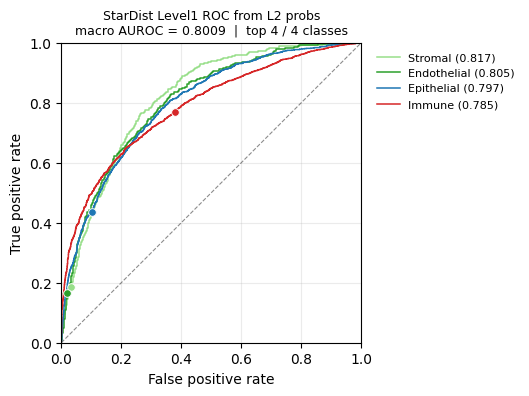


L12 sublineage (StarDist) ROC
  ROC colors: codex_pdac_intermediate (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/roc_stardist_level12.pdf


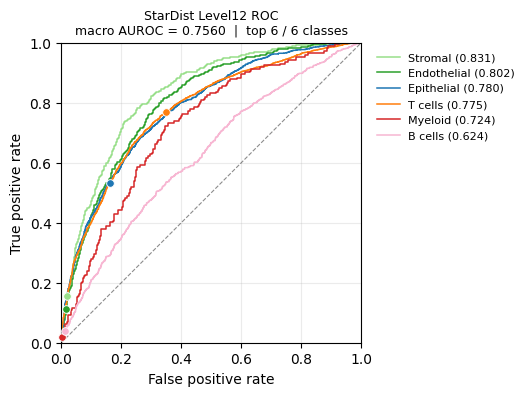

Saved: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/project_all_UNI/result/roc_stardist_level12.pdf
Skip L3 CNiche ROC: missing probs l3
Skip L4 TNiche ROC: missing probs l4
[StarDist] external metrics CSV
Skip L3 CNiche: missing preds_l3
Skip L4 TNiche: missing preds_l4
Current run metrics:
             timestamp                                       therapy_data  \
0  2026-08-21 01:04:12  Charvill-94_c001_v001_r001_reg001_stardist_mat...   

   best_epoch hce_lambda  hce_w1  hce_w2  hce_w12  hce_w_l12head  hce_w_l3  \
0           0       None     1.0     2.0      1.0            1.0       1.0   

   hce_w_l4  ...  insample_l12_macro_f1  insample_l12_weighted_f1  \
0       1.0  ...               0.312624                  0.534151   

   num_l1_head_classes  num_l12_classes  insample_l2_macro_auc  \
0                    4                6               0.763638   

   insample_l1_macro_auc  insample_l1_head_macro_auc  i

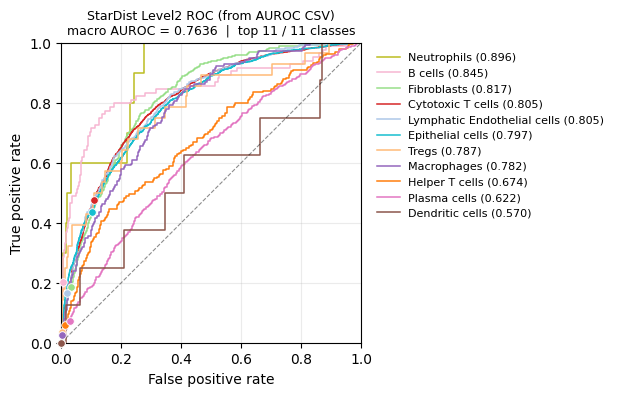

  Macro AUROC from CSV: 0.7636
StarDist matched h5ad: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/Charvill-94_c001_v001_r001_reg001_matched_features_stardist.h5ad
all_acc = 0.4872094967396756
all_macro_f1 = 0.23235869269794973


In [12]:
## Matched StarDist nuclei (with GT AUROC). Builds matched StarDist h5ad if missing.
pdac_cli.step_stardist(ctx)
print("StarDist matched h5ad:", ctx.matched_stardist_h5ad)
print("all_acc =", ctx.g.get("all_acc"))
print("all_macro_f1 =", ctx.g.get("all_macro_f1"))


## Notes

- PDAC demo core: `Charvill-94_c001_v001_r001_reg001` (coverslip c001).
- Training pool of 278 annotated cores is **not** used here; see the `_all` notebook.
- Incomplete_Cases (195 unlabeled) are also only in the `_all` notebook §6.

- Change `SAMPLE` in the dataset cell to run another annotated core.
- Cross-dataset training: `PDAC_train_validate_cv_UNIlabel_all.ipynb`.
- CLI: `python -u code/CODEX_pdac/PDAC_train_validate_cv_UNIlabel.py --sample Charvill-94_c001_v001_r001_reg001`.
- GPU: set `NCRT_CUDA_DEVICE` in the first runtime cell, then **Restart Kernel**.
